In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV

In [2]:
no_dummies = pd.read_csv('Step 4 - Final Dataset without dummies.csv')

In [3]:
no_dummies['Price'].nsmallest(10)

8470     4950.0
8469     5250.0
8468     5300.0
13066    5445.0
8467     5450.0
8466     5490.0
8464     5499.0
3071     5555.0
8465     5600.0
13059    5700.0
Name: Price, dtype: float64

In [4]:
scout_car = pd.read_csv('Step 4 - Final Dataset with dummies.csv')
scout_car

,Price,KM,Registration,Horsepower (kW),Previous Owners,Inspection new,Warranty (months),# of Doors,# of Seats,Displacement (cc),...,Country version_Poland,Country version_Spain,Upholstery Material_Full leather,Upholstery Material_Other,Upholstery Material_Part leather,Upholstery Material_Velour,Upholstery Material_alcantara,Upholstery Color_Brown,Upholstery Color_Grey,Upholstery Color_Other
0,15770.0,56013.0,2016.0,66.0,2,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
1,14500.0,80000.0,2017.0,141.0,0,0,0.0,3.0,4.0,1798.0,...,0,0,0,0,0,0,0,0,1,0
2,14640.0,83450.0,2016.0,85.0,1,0,0.0,5.0,4.0,1598.0,...,0,0,0,0,0,0,0,0,0,0
3,14500.0,73000.0,2016.0,66.0,1,0,0.0,3.0,4.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
4,16790.0,16200.0,2016.0,66.0,1,1,0.0,5.0,5.0,1422.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15095,39950.0,10.0,2016.0,147.0,0,0,0.0,5.0,5.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15096,39885.0,9900.0,2019.0,165.0,1,0,0.0,5.0,5.0,1798.0,...,0,0,0,0,0,0,0,0,0,0
15097,39875.0,15.0,2019.0,146.0,1,1,0.0,5.0,7.0,1997.0,...,0,0,1,0,0,0,0,0,0,0
15098,39700.0,10.0,2019.0,147.0,0,0,0.0,5.0,7.0,1997.0,...,0,0,0,0,1,0,0,0,0,0


# Unadjusted Linear Regression

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from scipy import stats

# Features
X = scout_car.drop(columns=['Price'])

# Target
y = scout_car['Price']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

LinearRegression()

In [6]:
y_pred = linreg.predict(X_test)
y_pred

array([32137.88905718, 12823.58246302, 38553.64281077, ...,
       10761.40286925,  4513.08001548, 20653.35597692])

In [7]:
# Create a new DataFrame showing the samples indices next to the non-dummy columns.
# This will allow us to compare results side-by-side with these categorial columns.
samples_no_dummies = no_dummies.loc[X_test.index]

# Build a new DataFrame compiling the results of the Linear Regression for each sample.
# We can also load categorical columns into this DataFrame.
linreg_init_results = pd.DataFrame()
linreg_init_results['make_model'] = samples_no_dummies['make_model']
linreg_init_results['Actual Price'] = y_test
linreg_init_results['Predicted Price'] = np.round(y_pred).astype(int)
linreg_init_results['Error'] = linreg_init_results['Predicted Price'] - linreg_init_results['Actual Price']
linreg_init_results['Squared Error'] = linreg_init_results['Error'] ** 2
linreg_init_results['Absolute Error'] = linreg_init_results['Error'].abs()
linreg_init_results

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
14845,Renault Espace,34985.0,32138,-2847.0,8105409.0,2847.0
14120,Renault Clio,11280.0,12824,1544.0,2383936.0,1544.0
14860,Renault Espace,38875.0,38554,-321.0,103041.0,321.0
884,Audi A1,14500.0,15844,1344.0,1806336.0,1344.0
411,Audi A1,15900.0,17040,1140.0,1299600.0,1140.0
...,...,...,...,...,...,...
499,Audi A1,13700.0,13545,-155.0,24025.0,155.0
668,Audi A1,12451.0,13206,755.0,570025.0,755.0
8028,Opel Corsa,12990.0,10761,-2229.0,4968441.0,2229.0
8495,Opel Corsa,7650.0,4513,-3137.0,9840769.0,3137.0


In [17]:
print(f"Mean squared error: {linreg_init_results['Squared Error'].mean()}")
print(f"Mean absolute error: {linreg_init_results['Absolute Error'].mean()}")
print(f"Median squared error: {linreg_init_results['Absolute Error'].median()}")

Mean squared error: 5605251.23013245
Mean absolute error: 1658.15
Median squared error: 1197.5


Let's verify that the results calculated from our DataFrame are identical to the "out-of-the-box" metrics Scikit-learn provides.

In [9]:
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"Median Absolute Error: {median_absolute_error(y_test, y_pred)}")

R2 Score: 0.9009513488653939
Mean Squared Error: 5605252.241853897
Mean Absolute Error: 1658.1499208874586
Median Absolute Error: 1197.4056613203138


In [19]:
linreg_init_results.nsmallest(10, 'Error')

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
12143,Opel Insignia,49350.0,31338,-18012.0,324432144.0,18012.0
12150,Opel Insignia,44970.0,27418,-17552.0,308072704.0,17552.0
3402,Audi A3,56100.0,41518,-14582.0,212634724.0,14582.0
15051,Renault Espace,49690.0,35432,-14258.0,203290564.0,14258.0
15021,Renault Espace,47450.0,34481,-12969.0,168194961.0,12969.0
14988,Renault Espace,44500.0,32617,-11883.0,141205689.0,11883.0
15062,Renault Espace,47990.0,36251,-11739.0,137804121.0,11739.0
12416,Opel Insignia,39990.0,28264,-11726.0,137499076.0,11726.0
11890,Opel Insignia,36990.0,25292,-11698.0,136843204.0,11698.0
15033,Renault Espace,45990.0,34739,-11251.0,126585001.0,11251.0


In [20]:
linreg_init_results.nlargest(10, 'Error')

,make_model,Actual Price,Predicted Price,Error,Squared Error,Absolute Error
10336,Opel Insignia,11600.0,24944,13344.0,178062336.0,13344.0
8471,Opel Corsa,10500.0,21969,11469.0,131537961.0,11469.0
3035,Audi A3,14250.0,24818,10568.0,111682624.0,10568.0
10400,Opel Insignia,8990.0,18954,9964.0,99281296.0,9964.0
10673,Opel Insignia,10500.0,18276,7776.0,60466176.0,7776.0
724,Audi A1,25900.0,33670,7770.0,60372900.0,7770.0
10381,Opel Insignia,10262.0,17507,7245.0,52490025.0,7245.0
10072,Opel Insignia,17999.0,25144,7145.0,51051025.0,7145.0
6137,Opel Astra,6950.0,13806,6856.0,47004736.0,6856.0
14611,Renault Espace,19900.0,26639,6739.0,45414121.0,6739.0


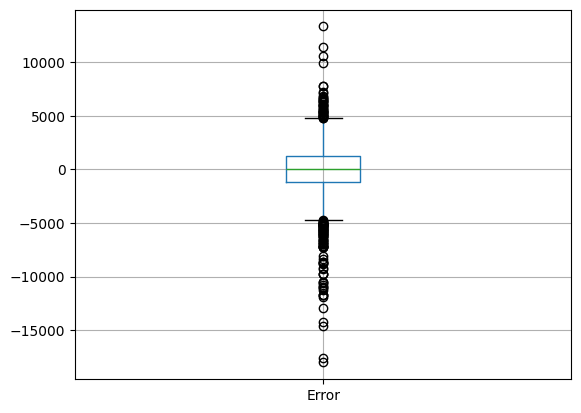

In [23]:
linreg_init_results.boxplot(column='Error')
plt.show()

In [25]:
linreg_init_sorted = linreg_init_results.sort_values(by='Error', ascending=False)
linreg_init_sorted.to_csv('Step 5 - Linreg init sorted by error.csv', index=False)

# Linear Regression with K-Fold Cross Validation

# Ridge

# Lasso

# Comparing Results